<a href="https://colab.research.google.com/github/Pubudu-98/Colab/blob/main/Data_Science_Project_EV_Data_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Testing Colab CPU & GPU*

In [1]:
import torch
import time

def compute(device):

    x = torch.rand(10000, 10000, device=device)

    start = time.time()

    y = x @ x

    torch.cuda.synchronize() if device == 'cuda' else None
    end = time.time()
    print(end-start)

In [2]:
compute('cpu') # CPU performence

28.36436629295349


In [3]:
compute('cuda') # GPU performence

0.6674556732177734


## **Data Science Life Cycle**


*   Business reqiurement
*   Data aquisition


*   Data processing
*   Data exploration


*   Data modeling
*   Deployment








**Import Libraries**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
data = pd.read_csv('/content/Electric_Vehicle_Data.csv')

**Load Data and Initial Inspection**

In [6]:
data.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJYGDEE1L,King,Seattle,WA,98122,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,0.0,37.0,125701579.0,POINT (-122.30839 47.610365),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
1,7SAYGDEE9P,Snohomish,Bothell,WA,98021,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,1.0,244285107.0,POINT (-122.179458 47.802589),PUGET SOUND ENERGY INC,5.306105e+10
2,5YJSA1E4XK,King,Seattle,WA,98109,2019,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,270.0,0.0,36.0,156773144.0,POINT (-122.34848 47.632405),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5YJSA1E27G,King,Issaquah,WA,98027,2016,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,210.0,0.0,5.0,165103011.0,POINT (-122.03646 47.534065),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
4,5YJYGDEE5M,Kitsap,Suquamish,WA,98392,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,23.0,205138552.0,POINT (-122.55717 47.733415),PUGET SOUND ENERGY INC,5.303594e+10


In [7]:
data.head(5)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJYGDEE1L,King,Seattle,WA,98122,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,0.0,37.0,125701579.0,POINT (-122.30839 47.610365),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
1,7SAYGDEE9P,Snohomish,Bothell,WA,98021,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,1.0,244285107.0,POINT (-122.179458 47.802589),PUGET SOUND ENERGY INC,5.306105e+10
2,5YJSA1E4XK,King,Seattle,WA,98109,2019,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,270.0,0.0,36.0,156773144.0,POINT (-122.34848 47.632405),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5YJSA1E27G,King,Issaquah,WA,98027,2016,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,210.0,0.0,5.0,165103011.0,POINT (-122.03646 47.534065),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
4,5YJYGDEE5M,Kitsap,Suquamish,WA,98392,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,23.0,205138552.0,POINT (-122.55717 47.733415),PUGET SOUND ENERGY INC,5.303594e+10


In [8]:
data.columns

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Base MSRP', 'Legislative District', 'DOL Vehicle ID',
       'Vehicle Location', 'Electric Utility', '2020 Census Tract'],
      dtype='object')

In [9]:
data.tail()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
95759,1C4JJXP66N,Pierce,Enumclaw,WA,98022,2022,JEEP,WRANGLER,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,21.0,0.0,31.0,205772227.0,POINT (-121.98953 47.20347),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.305307e+10
95760,5YJ3E1EAXJ,King,Bellevue,WA,98008,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,0.0,48.0,258246418.0,POINT (-122.11832 47.6245),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
95761,1G1FW6S01P,Island,Freeland,WA,98249,2023,CHEVROLET,BOLT EV,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,10.0,228136856.0,POINT (-122.544745 48.03024),PUGET SOUND ENERGY INC,5.302997e+10
95762,JTDKARFPXL,Thurston,Lacey,WA,98503,2020,TOYOTA,PRIUS PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25.0,0.0,22.0,104003525.0,POINT (-122.8285 47.03646),PUGET SOUND ENERGY INC,5.306701e+10
95763,1C4RJYD62N,Pierce,Orting,WA,98360,2022,JEEP,GRAND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
data.isnull().sum()

,0
VIN (1-10),0
County,0
City,0
State,0
Postal Code,0
Model Year,0
Make,0
Model,0
Electric Vehicle Type,1
Clean Alternative Fuel Vehicle (CAFV) Eligibility,1


In [11]:
data.describe()

,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,2020 Census Tract
count,95764.000000,95764.000000,95763.000000,95763.000000,95748.000000,9.576300e+04,9.576300e+04
mean,98192.707437,2020.560858,59.367230,1075.012896,31.539938,2.205009e+08,5.303043e+10
std,676.376986,2.950886,92.267474,8587.055858,14.395597,7.660943e+07,4.558924e+08
min,17013.000000,1998.000000,0.000000,0.000000,1.000000,4.777000e+03,6.029005e+09
25%,98040.000000,2019.000000,0.000000,0.000000,21.000000,1.821786e+08,5.303301e+10
50%,98112.000000,2022.000000,0.000000,0.000000,36.000000,2.283235e+08,5.303302e+10
75%,98233.000000,2023.000000,82.000000,0.000000,44.000000,2.547497e+08,5.303303e+10
max,99403.000000,2024.000000,337.000000,845000.000000,49.000000,4.789259e+08,5.307794e+10


**Data Types and Non-Null Values**

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95764 entries, 0 to 95763
Data columns (total 17 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   VIN (1-10)                                         95764 non-null  object 
 1   County                                             95764 non-null  object 
 2   City                                               95764 non-null  object 
 3   State                                              95764 non-null  object 
 4   Postal Code                                        95764 non-null  int64  
 5   Model Year                                         95764 non-null  int64  
 6   Make                                               95764 non-null  object 
 7   Model                                              95764 non-null  object 
 8   Electric Vehicle Type                              95763 non-null  object 
 9   Clean 

**Relating the Varialbes with Scatterplots**

In [13]:
data.columns

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Base MSRP', 'Legislative District', 'DOL Vehicle ID',
       'Vehicle Location', 'Electric Utility', '2020 Census Tract'],
      dtype='object')

<Axes: xlabel='Model Year', ylabel='Electric Range'>

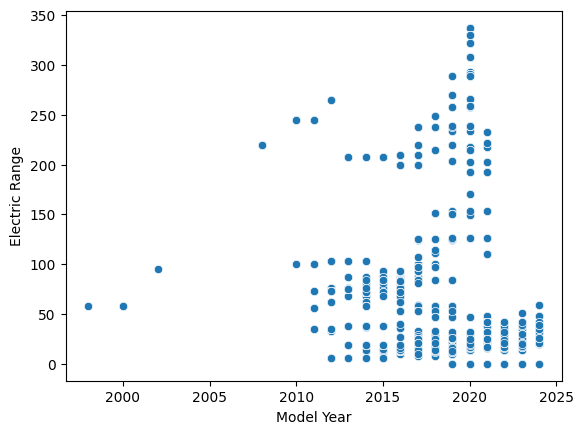

In [14]:
sns.scatterplot(data=data, x='Model Year', y='Electric Range')

**The scatterplot helps us visualize how the electric range of vehicles has changed over the years.**




*   Technological Advancement: If there's an upward trend, it suggests that newer model years generally offer a longer electric range due to advancements in battery technology and vehicle design.
*   Variability: The spread of points at each model year can indicate the diversity in electric ranges available during that period.